# 02. Modeling Trees

In [172]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Transformer

CONFIG = json.load(open("config.json"))

W, H = CONFIG["grid"]["width"], CONFIG["grid"]["height"]
MINX, MINY = CONFIG["grid"]["minx"], CONFIG["grid"]["miny"]
MAXX, MAXY = CONFIG["grid"]["maxx"], CONFIG["grid"]["maxy"]
CELL = CONFIG["cell_size"]
LAT, LON = CONFIG["lat"], CONFIG["lon"]

to_m = Transformer.from_crs(CONFIG["crs"]["wgs84"], CONFIG["crs"]["mga55"], always_xy=True)

In [173]:
dsm = np.load("out/rasters/dsm_buildings.npy")
canopy8 = np.load("out/rasters/dsm_canopy.npy")     # the nominal 8 m slab from 00

print(f"grid       {W} x {H} cells at {CELL:.0f} m")
print(f"buildings  max {dsm.max():5.1f} m   cover {(dsm > 0).mean() * 100:4.1f}%")
print(f"canopy     max {canopy8.max():5.1f} m   cover {(canopy8 > 0).mean() * 100:4.1f}%")

grid       2438 x 2485 cells at 2 m
buildings  max 298.0 m   cover 23.1%
canopy     max   8.0 m   cover  7.5%


## Downloading Council Tree Dataset

In [174]:
# The whole council set, not just the bbox: the height fit downstream wants every
# measured trunk it can get, and the export is only 18 MB.
import urllib.request

COM = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/{}/exports/csv"
TREES = "data/trees.csv"
os.makedirs("data", exist_ok=True)

if os.path.exists(TREES) and os.path.getsize(TREES) > 1000:
    print(f"cached   trees.csv  ({os.path.getsize(TREES) / 1e6:.1f} MB)")
else:
    print("fetching trees ...")
    urllib.request.urlretrieve(COM.format("trees-with-species-and-dimensions-urban-forest"), TREES)
    print(f"done     trees.csv  ({os.path.getsize(TREES) / 1e6:.1f} MB)")

cached   trees.csv  (18.2 MB)


In [175]:
trees = pd.read_csv(TREES, sep=";", low_memory=False)   # CoM exports semicolon-delimited

print(f"{len(trees)} trees, {len(trees.columns)} fields\n")
print("fields:", list(trees.columns), "\n")

print("one record:")
for k, v in trees.iloc[0].items():
    print(f"  {k:30s} {v}")

82064 trees, 20 fields

fields: ['com_id', 'common_name', 'scientific_name', 'genus', 'family', 'diameter_breast_height', 'year_planted', 'date_planted', 'age_description', 'useful_life_expectency', 'useful_life_expectency_value', 'precinct', 'located_in', 'uploaddate', 'coordinatelocation', 'latitude', 'longitude', 'easting', 'northing', 'geolocation'] 

one record:
  com_id                         1023218
  common_name                    London Plane
  scientific_name                Platanus x acerifolia
  genus                          Platanus
  family                         Platanaceae
  diameter_breast_height         27.0
  year_planted                   1900
  date_planted                   1900-01-01
  age_description                Mature
  useful_life_expectency         31 - 40 years
  useful_life_expectency_value   40
  precinct                       Carlton
  located_in                     Street
  uploaddate                     nan
  coordinatelocation             -37.804

## The tree diameter

In [176]:
# diameter_breast_height: trunk width in cm, measured 1.3 m off the ground.
# The only physical dimension CoM records. No height anywhere in the file.
dbh = trees["diameter_breast_height"]
print(f"measured {dbh.notna().sum():6d}    null {dbh.isna().sum():6d}  ({dbh.isna().mean() * 100:.0f}%)\n")

for q in (0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100):
    print(f"  p{q:<5.4g} {np.percentile(dbh.dropna(), q):9.1f} cm")

measured  37201    null  44863  (55%)

  p0           1.0 cm
  p1           4.0 cm
  p5          10.0 cm
  p25         18.0 cm
  p50         30.0 cm
  p75         45.0 cm
  p95         80.0 cm
  p99        120.0 cm
  p99.9      250.0 cm
  p100     26027.0 cm


In [177]:
# Clamp to the 99.9 percentile the 100 percentile is likely a human error
DBH_MIN, DBH_MAX = 1.0, 250.0

print("largest five (cm):", sorted(dbh.dropna(), reverse=True)[:5])
print(f"above {DBH_MAX:.0f} cm: {(dbh > DBH_MAX).sum()} trees   below {DBH_MIN:.0f} cm: {(dbh < DBH_MIN).sum()}")

# Clamped, not dropped: the tree is real even where its number isn't. Anything outside the
trees["dbh_real"] = dbh.between(DBH_MIN, DBH_MAX)
trees["dbh"] = dbh.clip(DBH_MIN, DBH_MAX)
print(f"\nusable trunks {trees.dbh_real.sum()} ({trees.dbh_real.mean() * 100:.0f}%)")

largest five (cm): [26027.0, 2028.0, 860.0, 565.0, 459.0]
above 250 cm: 29 trees   below 1 cm: 0

usable trunks 37172 (45%)


## Obtaining height from trunk diameter

### Downloading USDA Urban Tree Database

In [178]:
import zipfile

# Download the USDA Urban Tree Database (UTD) with height and diameter ground truths
UTD_URL = "https://www.fs.usda.gov/rds/archive/products/RDS-2016-0005/RDS-2016-0005.zip"
UTD = "data/RDS-2016-0005.zip"

if os.path.exists(UTD) and os.path.getsize(UTD) > 1000:
    print(f"cached   RDS-2016-0005.zip  ({os.path.getsize(UTD) / 1e6:.1f} MB)")
else:
    print("fetching urban tree database ...")
    urllib.request.urlretrieve(UTD_URL, UTD)
    print(f"done     RDS-2016-0005.zip  ({os.path.getsize(UTD) / 1e6:.1f} MB)")

cached   RDS-2016-0005.zip  (1.1 MB)


In [179]:
utd = pd.read_csv(zipfile.ZipFile(UTD).open("Data/TS3_Raw_tree_data.csv"), low_memory=False)

print(f"{len(utd)} measured trees, {len(utd.columns)} fields")
print(f"{utd.Region.nunique()} regions, {utd.City.nunique()} cities\n")

# Only take the Name, DBH, Height and Crown Base
for k in ("ScientificName", "DBH (cm)", "TreeHt (m)", "CrnBase"):
    print(f"{k:16s} {utd[k].iloc[7]}")

14487 measured trees, 41 fields
17 regions, 17 cities

ScientificName   Fraxinus pennsylvanica 'Marshall'
DBH (cm)         2.5
TreeHt (m)       2.0
CrnBase          -1.0


In [180]:
# Only chose regions that are similar climate to Melbourne (California) drop the others
CA = ["InlEmp", "InlVal", "NoCalC", "SacVal", "SoCalC"]

for r, n in utd.Region.value_counts().items():
    print(f"  {r:8s} {n:5d}  {'KEEP' if r in CA else ''}")

utd_ca = utd[utd.Region.isin(CA)].copy()
print(f"\nkept {len(utd_ca)} of {len(utd)} trees ({len(utd_ca) / len(utd) * 100:.0f}%) "
      f"across {utd_ca.City.nunique()} Californian cities:")
print("  " + ", ".join(sorted(utd_ca.City.unique())))

  SacVal    1001  KEEP
  PacfNW     994  
  TpIntW     923  
  Tropic     918  
  NoCalC     912  KEEP
  CenFla     895  
  InlEmp     888  KEEP
  LoMidW     877  
  GulfCo     872  
  NMtnPr     867  
  InterW     833  
  NoEast     831  
  Piedmt     828  
  SWDsrt     827  
  MidWst     760  
  InlVal     634  KEEP
  SoCalC     627  KEEP

kept 4062 of 14487 trees (28%) across 5 Californian cities:
  Berkeley, CA, Claremont, CA, Modesto, CA, Sacramento, CA, Santa Monica, CA


### Genus → form class

In [181]:
# 192 genera is too many shapes to model and too few trees each to fit. Five form
# classes plus palms: a 30 m plane, a 12 m callistemon and a palm are three
# different shadows and one curve cannot be all three.
def cls_map(names, label):
    return {g: label for g in names.split()}

GENUS_CLASS = {}
GENUS_CLASS.update(cls_map(
    "Platanus Ulmus Quercus Fraxinus Acer Celtis Zelkova Liquidambar Populus "
    "Tilia Aesculus Gleditsia Robinia Liriodendron Salix Juglans Fagus Carpinus "
    "Nyssa Catalpa Paulownia Alnus Morus Sophora Styphnolobium", "large_broadleaf"))
GENUS_CLASS.update(cls_map(
    "Eucalyptus Corymbia Angophora Lophostemon Syncarpia", "eucalypt"))
GENUS_CLASS.update(cls_map(
    "Pinus Cedrus Cupressus Sequoia Sequoiadendron Taxodium Metasequoia Araucaria "
    "Agathis Callitris Cryptomeria Juniperus Calocedrus Pseudotsuga Thuja Picea "
    "Abies Wollemia Podocarpus", "conifer"))
GENUS_CLASS.update(cls_map(
    "Ficus Cinnamomum Magnolia Jacaranda Schinus Casuarina Allocasuarina "
    "Tristaniopsis Acacia Brachychiton Pittosporum Metrosideros Ceratonia "
    "Koelreuteria Pistacia Ginkgo Cupaniopsis Melia Syzygium Elaeocarpus "
    "Waterhousea Flindersia Stenocarpus Buckinghamia Agonis Harpephyllum "
    "Backhousia Cercis Grevillea Hymenosporum Toona Ligustrum", "evergreen_medium"))
GENUS_CLASS.update(cls_map(
    "Melaleuca Callistemon Prunus Pyrus Malus Lagerstroemia Betula Olea Crataegus "
    "Photinia Banksia Bursaria Hakea Leptospermum Geijera Callicoma Acmena "
    "Dodonaea Kunzea Westringia Rhaphiolepis Michelia Laurus Arbutus Nerium "
    "Eriobotrya Citrus Cotinus Viburnum", "small_tree"))
PALMS = set("Phoenix Washingtonia Livistona Trachycarpus Butia Syagrus Howea "
            "Archontophoenix Rhopalostylis Chamaerops Jubaea Dypsis Cordyline "
            "Dracaena Yucca".split())
DEFAULT_CLASS = "evergreen_medium"

def form_class(genus):
    return "palm" if genus in PALMS else GENUS_CLASS.get(genus, DEFAULT_CLASS)

In [182]:
trees["cls"] = trees.genus.map(form_class)
named = trees.genus.isin(GENUS_CLASS) | trees.genus.isin(PALMS)

print(f"{trees.genus.nunique()} genera, {(~named).sum()} trees "
      f"({(~named).mean() * 100:.1f}%) in a genus the map has never heard of "
      f"-> {DEFAULT_CLASS}\n")
for c, n in trees.cls.value_counts().items():
    print(f"  {c:18s} {n:6d}  {n / len(trees) * 100:4.1f}%")

print("\nthe genera Melbourne is actually full of:")
for g, n in trees.genus.value_counts().head(12).items():
    print(f"  {g:16s} {n:6d}  ->  {form_class(g)}")

192 genera, 1766 trees (2.2%) in a genus the map has never heard of -> evergreen_medium

  evergreen_medium    25789  31.4%
  eucalypt            24752  30.2%
  large_broadleaf     19468  23.7%
  small_tree           8543  10.4%
  conifer              2635   3.2%
  palm                  877   1.1%

the genera Melbourne is actually full of:
  Eucalyptus        17687  ->  eucalypt
  Acacia             7667  ->  evergreen_medium
  Ulmus              6102  ->  large_broadleaf
  Platanus           5646  ->  large_broadleaf
  Corymbia           4694  ->  eucalypt
  Allocasuarina      4010  ->  evergreen_medium
  Casuarina          2770  ->  evergreen_medium
  Quercus            2584  ->  large_broadleaf
  Ficus              1705  ->  evergreen_medium
  Bursaria           1574  ->  small_tree
  Angophora          1465  ->  eucalypt
  Melaleuca          1446  ->  small_tree


In [183]:
# Rename columns to shorthands
utd_ca = utd_ca.rename(columns={"DBH (cm)": "dbh", "TreeHt (m)": "h", "CrnBase": "cb"})
utd_ca["genus"] = utd_ca.ScientificName.str.split().str[0]  # Take the first word (the genus)
utd_ca["cls"] = utd_ca.genus.map(form_class)                # Apply the class mapping from earlier

print(f"{utd_ca.genus.nunique()} genera, {utd_ca.ScientificName.nunique()} species\n")

# Print out number of valid readings in each column for each class
print(f"{'class':18s} {'trees':>6s} {'-> H(DBH)':>10s} {'-> crown base':>14s}")
for c, n in utd_ca.cls.value_counts().items():
    s = utd_ca[utd_ca.cls == c]
    print(f"  {c:16s} {n:6d} {((s.dbh > 0) & (s.h > 0)).sum():10d} "
          f"{((s.h > 0) & (s.cb >= 0)).sum():14d}")

39 genera, 69 species

class               trees  -> H(DBH)  -> crown base
  large_broadleaf    1645       1633           1620
  evergreen_medium   1287       1277           1264
  small_tree          495        492            484
  conifer             401        399            397
  eucalypt            136        135            133
  palm                 98         98             98


### Fitting the Curve for `large_broadleaf`

In [184]:
from scipy.optimize import curve_fit

# the class ceilings from the form-class table above -- pinned, never fitted
MATURE_H = {"large_broadleaf": 33.0, "eucalypt": 35.0, "conifer": 30.0,
            "evergreen_medium": 22.0, "small_tree": 13.0}

def chapman(D, b, c, a):
    return 1.3 + a * (1.0 - np.exp(-b * D)) ** c

lb = utd_ca[(utd_ca.cls == "large_broadleaf") & (utd_ca.dbh > 0) & (utd_ca.h > 0)]
a_lb = MATURE_H["large_broadleaf"]

# Least squares curve fit using Chapman-Richards
(b_lb, c_lb), _ = curve_fit(lambda D, b, c: chapman(D, b, c, a_lb),
                            lb.dbh, lb.h, p0=[0.02, 1.0], maxfev=20000)

print(f"large_broadleaf, n = {len(lb)}   DBH {lb.dbh.min():.0f}-{lb.dbh.max():.0f} cm")
print(f"  a = {a_lb:.1f} (pinned)   b = {b_lb:.5f}   c = {c_lb:.4f}")
print(f"  a 60 cm trunk -> {chapman(60.0, b_lb, c_lb, a_lb):.1f} m")

large_broadleaf, n = 1633   DBH 1-169 cm
  a = 33.0 (pinned)   b = 0.00796   c = 0.7882
  a 60 cm trunk -> 16.7 m


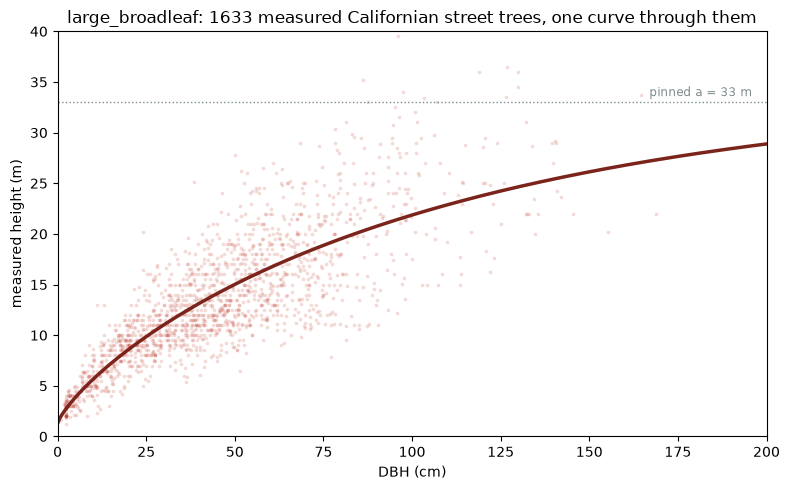

In [185]:
fig, ax = plt.subplots(figsize=(8, 5))
grid = np.linspace(0, 200, 300)

ax.scatter(lb.dbh, lb.h, s=7, alpha=0.18, color="#c0392b", lw=0)
ax.plot(grid, chapman(grid, b_lb, c_lb, a_lb), color="#7b241c", lw=2.5)
ax.axhline(a_lb, color="#7f8c8d", lw=1, ls=":")
ax.text(196, a_lb + 0.6, f"pinned a = {a_lb:.0f} m", fontsize=8.5, ha="right", color="#7f8c8d")

ax.set_xlabel("DBH (cm)"); ax.set_ylabel("measured height (m)")
ax.set_xlim(0, 200); ax.set_ylim(0, 40)
ax.set_title(f"large_broadleaf: {len(lb)} measured Californian street trees, "
             f"one curve through them")
fig.tight_layout()

### Fit the other 4 trees

In [186]:
CLASS_COEF = {}
print(f"{'class':18s} {'n':>5s} {'a (pinned)':>11s} {'b':>9s} {'c':>8s}")
for c, a in MATURE_H.items():
    s = utd_ca[(utd_ca.cls == c) & (utd_ca.dbh > 0) & (utd_ca.h > 0)]
    (b, k), _ = curve_fit(lambda D, b, k: chapman(D, b, k, a), s.dbh, s.h,
                          p0=[0.02, 1.0], maxfev=20000)
    CLASS_COEF[c] = (a, float(b), float(k))
    print(f"  {c:16s} {len(s):5d} {a:11.1f} {b:9.5f} {k:8.4f}")

class                  n  a (pinned)         b        c
  large_broadleaf   1633        33.0   0.00796   0.7882
  eucalypt           135        35.0   0.01413   1.0757
  conifer            399        30.0   0.02185   1.5222
  evergreen_medium  1277        22.0   0.00955   0.7396
  small_tree         492        13.0   0.02806   0.9351


### Measuring Palm Tree DBH vs Height Correlation

A palm is not a tree in the way the other five are. It thickens once, early, and after that
only gets taller — the trunk is about as wide at 4 m as it is at 20 m. So palms take a flat height instead. **10 m**, stated rather than fitted

In [187]:
print("corr(DBH, measured height) by class:")
for c in list(MATURE_H) + ["palm"]:
    s = utd_ca[(utd_ca.cls == c) & (utd_ca.dbh > 0) & (utd_ca.h > 0)]
    print(f"  {c:18s} {np.corrcoef(s.dbh, s.h)[0, 1]:+.2f}   (n {len(s)})")

PALM_H = 10.0                 # m; a palm's trunk does not track its height at all
palms = utd_ca[(utd_ca.cls == "palm") & (utd_ca.dbh > 0) & (utd_ca.h > 0)]
print(f"\nCalifornian palms here: median {palms.h.median():.0f} m, "
      f"mostly {palms.genus.value_counts().index[0]} -> not Melbourne. flat {PALM_H:.0f} m instead.")

corr(DBH, measured height) by class:
  large_broadleaf    +0.80   (n 1633)
  eucalypt           +0.66   (n 135)
  conifer            +0.84   (n 399)
  evergreen_medium   +0.78   (n 1277)
  small_tree         +0.76   (n 492)
  palm               +0.38   (n 98)

Californian palms here: median 16 m, mostly Washingtonia -> not Melbourne. flat 10 m instead.


### Full curve fitting results

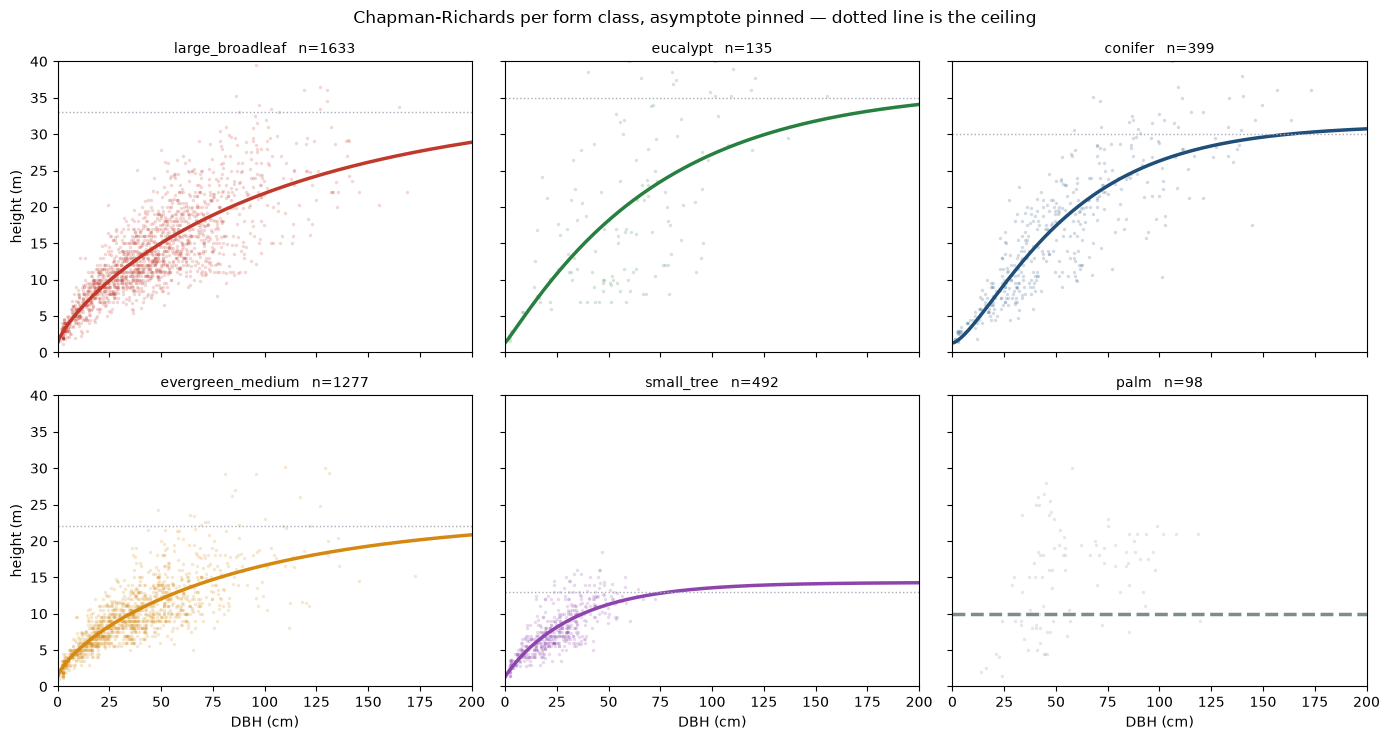

In [188]:
COLORS = {"large_broadleaf": "#c0392b", "eucalypt": "#27803f", "conifer": "#1f4e79",
          "evergreen_medium": "#d68910", "small_tree": "#8e44ad"}
grid = np.linspace(0, 200, 300)

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5), sharex=True, sharey=True)
for ax, c in zip(axes.ravel(), list(CLASS_COEF) + ["palm"]):
    s = utd_ca[(utd_ca.cls == c) & (utd_ca.dbh > 0) & (utd_ca.h > 0)]
    col = COLORS.get(c, "#7f8c8d")
    ax.scatter(s.dbh, s.h, s=6, alpha=0.2, color=col, lw=0)
    if c == "palm":
        ax.axhline(PALM_H, color="#7f8c8d", lw=2.5, ls="--")
    else:
        a, b, k = CLASS_COEF[c]
        ax.plot(grid, chapman(grid, b, k, a), color=col, lw=2.5)
        ax.axhline(a, color="#aab", lw=1, ls=":")
    ax.set_title(f"{c}   n={len(s)}", fontsize=10)

axes[0, 0].set_ylim(0, 40); axes[0, 0].set_xlim(0, 200)
for ax in axes[1]: ax.set_xlabel("DBH (cm)")
for ax in axes[:, 0]: ax.set_ylabel("height (m)")
fig.suptitle("Chapman-Richards per form class, asymptote pinned — dotted line is the ceiling",
             fontsize=12)
fig.tight_layout()

### Test curve fitting to a random tree

In [189]:
import math

H_MIN, H_MAX = 2.0, 40.0      # m; the tallest Melbourne street and park trees are ~35-40 m

def height(dbh, cls):
    """Chapman-Richards H(DBH). dbh in cm, H in m."""
    a, b, c = CLASS_COEF[cls]
    return 1.3 + a * (1.0 - math.exp(-b * dbh)) ** c

In [190]:
# A worked example on the first record in the tree dataset
t0 = trees.iloc[0]
print(f"{t0.common_name}  ({t0.genus})   DBH {t0.dbh:.0f} cm   class {t0.cls}")
print(f"  H = 1.3 + {CLASS_COEF[t0.cls][0]:.0f} * (1 - exp(-{CLASS_COEF[t0.cls][1]} * {t0.dbh:.0f}))"
      f"^{CLASS_COEF[t0.cls][2]}  =  {height(t0.dbh, t0.cls):.1f} m")

London Plane  (Platanus)   DBH 27 cm   class large_broadleaf
  H = 1.3 + 33 * (1 - exp(-0.007959808569988095 * 27))^0.7882260701680829  =  10.3 m


## Calculating the Crown Base

A height on its own still gives a solid block so we need the crown base to model the crown and stick
*stop*:

```
              . : : : : : : : .              <-- crown top   H = 1.3 + a(1-e^-bD)^c
           . : : : : : : : : : : .                                                 
          : : : : : : : : : : : : :                                                
           ' : : : : : : : : : : '                                                 
              ' : : : : : : '                <-- crown base B                      
                    | |                                                            
                    | |                       the stick. Nothing here to           
                    | |                       stop a low beam.                     
                    | |
      ______________|_|______________         <-- ground
                    D
              (trunk diameter, measured at 1.3 m up)
```

To get the Crown base it is measured directly from the USDA database, using a **linear in H**:
$$B = m\,H + c$$


In [191]:
# One straight line per class through the USDA (height, crown base) pairs.
CBH_COEF = {}
print(f"{'class':18s} {'n':>6s} {'m':>8s} {'c':>9s}   B at H=10 m")
for c in list(MATURE_H) + ["palm"]:
    s = utd_ca[(utd_ca.cls == c) & (utd_ca.h > 0) & (utd_ca.cb >= 0)]
    m, k = np.polyfit(s.h, s.cb, 1)          # B = m*H + c, ordinary least squares
    CBH_COEF[c] = (round(float(m), 4), round(float(k), 4))
    print(f"  {c:16s} {len(s):6d} {m:8.4f} {k:9.4f} {m * 10 + k:11.1f} m")

CBH_MAX_RATIO = 0.90        # constrain so a crown is never less than 10% of the tree

class                   n        m         c   B at H=10 m
  large_broadleaf    1620   0.1451    1.3293         2.8 m
  eucalypt            133   0.3487   -0.1599         3.3 m
  conifer             397   0.1247    0.7946         2.0 m
  evergreen_medium   1264   0.1373    1.5573         2.9 m
  small_tree          484   0.1708    1.1401         2.8 m
  palm                 98   0.8630   -2.4151         6.2 m


In [192]:
def crown_base(h, cls):
    m = np.full(np.shape(h), CBH_COEF[DEFAULT_CLASS][0])
    c = np.full(np.shape(h), CBH_COEF[DEFAULT_CLASS][1])
    for k, (mk, ck) in CBH_COEF.items():
        sel = np.asarray(cls) == k
        m[sel], c[sel] = mk, ck
    return np.clip(m * np.asarray(h, float) + c, 0.0, CBH_MAX_RATIO * np.asarray(h, float))

In [193]:
h0 = height(t0.dbh, t0.cls)
b0 = float(crown_base(h0, t0.cls))
print(f"{t0.common_name}   H {h0:.1f} m   crown base {b0:.1f} m   crown depth {h0 - b0:.1f} m")
print(f"a 1.7 m pedestrian stands {'UNDER' if b0 > 1.7 else 'inside'} that crown")

London Plane   H 10.3 m   crown base 2.8 m   crown depth 7.5 m
a 1.7 m pedestrian stands UNDER that crown


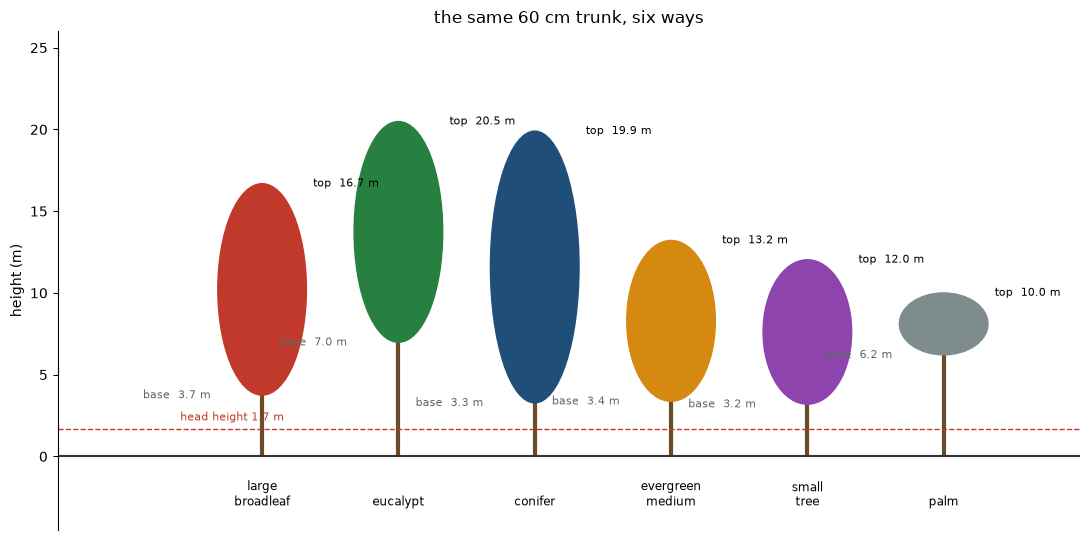

In [194]:
from matplotlib.patches import Ellipse

DBH_DEMO = 60.0                     # cm; one solid mature street tree of each class
CROWN_COLORS = dict(COLORS, palm="#7f8c8d")

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, c in enumerate(list(CLASS_COEF) + ["palm"]):
    h = PALM_H if c == "palm" else height(DBH_DEMO, c)
    b = float(crown_base(h, c))
    x = i * 4.0
    ax.plot([x, x], [0, b + 0.4], color="#6b4b2a", lw=3, solid_capstyle="butt", zorder=1)
    ax.add_patch(Ellipse((x, (b + h) / 2), 2.6, h - b, color=CROWN_COLORS[c], zorder=2))
    ax.annotate(f"top  {h:4.1f} m", (x + 1.5, h), fontsize=8, va="center")
    ax.annotate(f"base {b:4.1f} m", (x - 1.5, b), fontsize=8, va="center", ha="right", color="#666")
    ax.text(x, -3.0, c.replace("_", "\n"), ha="center", fontsize=8.5)

ax.axhline(0, color="#333", lw=1.5)
ax.axhline(1.7, color="#c0392b", lw=1, ls="--")
ax.text(-2.4, 2.2, "head height 1.7 m", fontsize=8, color="#c0392b")
ax.set_ylabel("height (m)"); ax.set_ylim(-4.5, 26); ax.set_xlim(-6, 24)
ax.set_xticks([]); ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.set_title(f"the same {DBH_DEMO:.0f} cm trunk, six ways")
fig.tight_layout()

## Imputing trees with no DBH (diameter breast height)

In [195]:
MIN_GROUP = 20   # Sample real trunks needed to generate a group median

real = trees[trees.dbh_real]
grp = real.groupby(["cls", "age_description"]).dbh
med = grp.median()[grp.size() >= MIN_GROUP]
gmed = float(real.dbh.median())

print(f"age_description: {list(trees.age_description.dropna().unique())}\n")
print(f"{len(med)} groups with >= {MIN_GROUP} real trunks (of {grp.ngroups}):\n")
for (c, a), v in med.items():
    print(f"  {c:18s} {a:22s} {v:5.1f} cm   (n {grp.size()[(c, a)]:5d})")
print(f"\nglobal median for anything else: {gmed:.1f} cm")

age_description: ['Mature', 'Unestablished', 'Semi-mature', 'Planter box']

12 groups with >= 20 real trunks (of 19):

  conifer            Mature                  30.0 cm   (n  1198)
  conifer            Semi-mature             20.0 cm   (n   263)
  eucalypt           Mature                  25.0 cm   (n  9835)
  eucalypt           Semi-mature             30.0 cm   (n  1260)
  evergreen_medium   Mature                  23.0 cm   (n  5783)
  evergreen_medium   Semi-mature             20.0 cm   (n  2541)
  large_broadleaf    Mature                  37.0 cm   (n 12065)
  large_broadleaf    Semi-mature             30.0 cm   (n  1451)
  palm               Mature                  42.0 cm   (n   507)
  palm               Semi-mature             30.0 cm   (n    99)
  small_tree         Mature                  23.0 cm   (n  1405)
  small_tree         Semi-mature             20.0 cm   (n   734)

global median for anything else: 30.0 cm


In [196]:
keys = list(zip(trees.cls, trees.age_description))
filled = np.array([med.get(k, gmed) for k in keys])

trees["dbh"] = np.where(trees.dbh_real, trees.dbh, filled)
print(f"imputed {(~trees.dbh_real).sum()} trunks; "
      f"median over the whole set now {trees.dbh.median():.1f} cm "
      f"(measured-only median was {gmed:.1f} cm)")

imputed 44892 trunks; median over the whole set now 25.0 cm (measured-only median was 30.0 cm)


In [197]:
d = trees.dbh.to_numpy()
h = np.full(len(trees), PALM_H)                    # palms never touch the curve
for c, (a, b, k) in CLASS_COEF.items():
    sel = (trees.cls == c).to_numpy()
    h[sel] = 1.3 + a * (1.0 - np.exp(-b * d[sel])) ** k

trees["h"] = np.clip(h, H_MIN, H_MAX)
print(f"H over {len(trees)} trees:  mean {trees.h.mean():.1f}  median {trees.h.median():.1f}"
      f"  p95 {np.percentile(trees.h, 95):.1f}  max {trees.h.max():.1f} m")

H over 82064 trees:  mean 10.3  median 9.8  p95 18.1  max 34.7 m


## Imputing Tree with age consideration

In [198]:
GROWTH_CAP = 0.75        # m/yr; generous for an urban street tree
YEAR = 2026
BASE = 1.3

UNKNOWN = 1900          # CoM uses this as a year placeholder

yr = trees.year_planted.fillna(0).astype(int).to_numpy()
is_unknown = yr <= UNKNOWN      # 1900 placeholder, and the 0s from fillna
is_future  = yr > YEAR          # typos like 2062
has_year   = ~is_unknown & ~is_future
age = np.where(has_year, YEAR - yr, -1)         # -1 = no usable year

cap = BASE + GROWTH_CAP * age

imputed = (~trees.dbh_real).to_numpy()      # trunk was guessed, not measured
too_tall = (age > 0) & (h > cap)            # taller than its planting year allows
capped       = too_tall & imputed           # cap the tree because the imputation made it too tall
contradicted = too_tall & ~imputed          # trees that arent imputed use ground truth instead

print(f"year_planted == 1900 (unknown placeholder): {(yr == 1900).sum()}")
print(f"usable planting years:                      {(age > 0).sum()}\n")
print(f"imputed trees pulled down to the cap:  {capped.sum()}")
print(f"measured trees over the cap, left as they are: {contradicted.sum()}")

trees["h"] = np.where(capped, np.maximum(cap, H_MIN), trees.h)

year_planted == 1900 (unknown placeholder): 26521
usable planting years:                      55543

imputed trees pulled down to the cap:  21825
measured trees over the cap, left as they are: 5951


In [199]:
print(f"{'genus':16s} {'n':>6s} {'p10':>6s} {'median':>7s} {'p90':>6s}   H (m)")
for g in ("Platanus", "Ulmus", "Eucalyptus", "Corymbia", "Quercus", "Casuarina",
          "Callistemon", "Phoenix"):
    v = trees.h[trees.genus == g]
    print(f"{g:16s} {len(v):6d} {np.percentile(v, 10):6.1f} {v.median():7.1f} "
          f"{np.percentile(v, 90):6.1f}   -> {form_class(g)}")

genus                 n    p10  median    p90   H (m)
Platanus           5646    7.2    12.5   16.7   -> large_broadleaf
Ulmus              6102    5.7    12.5   20.2   -> large_broadleaf
Eucalyptus        17687    4.4    10.8   12.5   -> eucalypt
Corymbia           4694    5.3    10.8   18.1   -> eucalypt
Quercus            2584    3.5    10.6   16.7   -> large_broadleaf
Casuarina          2770    5.0     7.3    7.9   -> evergreen_medium
Callistemon        1332    2.8     6.6    7.8   -> small_tree
Phoenix             445   10.0    10.0   10.0   -> palm


## Joining fitted tree heights to canopy polygons

In [200]:
import shapely
from shapely.geometry import shape
from shapely import STRtree

feats = json.load(open("data/canopy.geojson"))["features"]

def to_mga(geom):
    return shapely.transform(geom, lambda c: np.column_stack(to_m.transform(c[:, 0], c[:, 1])))

polys = np.array([to_mga(shape(f["geometry"])) for f in feats if f.get("geometry")], dtype=object)
print(f"{len(polys)} canopy polygons   fields: {list(feats[0]['properties'])}")
print(f"areas: median {np.median(shapely.area(polys)):.0f} m2   "
      f"max {shapely.area(polys).max():.0f} m2")

23578 canopy polygons   fields: ['geo_point_2d']
areas: median 9 m2   max 70909 m2


In [201]:
x, y = to_m.transform(trees.longitude.to_numpy(), trees.latitude.to_numpy())
pts = shapely.points(np.column_stack([x, y]))
rtree = STRtree(pts)

h_tree = trees.h.to_numpy()
cls_tree = trees.cls.to_numpy()

pi, ti = rtree.query(polys, predicate="intersects")     # (polygon index, tree index) pairs
ph = np.full(len(polys), np.nan)
np.fmax.at(ph, pi, h_tree[ti])                          # tallest point inside wins
inside = np.isfinite(ph)
print(f"inside a polygon:  {inside.sum()} polygons ({inside.mean() * 100:.1f}%), "
      f"{len(np.unique(ti))} trees used")

inside a polygon:  8328 polygons (35.3%), 18378 trees used


In [202]:
JOIN_RADIUS = 5.0        # m; a polygon this close to a tree is that tree

miss = np.where(~inside)[0]
near = rtree.nearest(polys[miss])
dist = shapely.distance(polys[miss], pts[near])
ok = dist <= JOIN_RADIUS
ph[miss[ok]] = h_tree[near[ok]]

matched = np.isfinite(ph)
area = shapely.area(polys)
print(f"nearest <= {JOIN_RADIUS:.0f} m:  {ok.sum()} polygons ({ok.mean() * 100:.1f}% of the misses)")
print(f"still unmatched: {(~matched).sum()} polygons ({(~matched).mean() * 100:.1f}%) — but only "
      f"{area[~matched].sum() / area.sum() * 100:.1f}% of the canopy AREA")
print(f"  median area  matched {np.median(area[matched]):6.0f} m2   "
      f"unmatched {np.median(area[~matched]):5.0f} m2")

nearest <= 5 m:  3105 polygons (20.4% of the misses)
still unmatched: 12145 polygons (51.5%) — but only 21.1% of the canopy AREA
  median area  matched     26 m2   unmatched     3 m2


In [203]:
# Half the polygons are unmatched, but they are the small ones — private-garden crowns and
# self-sown scrub the council never inventoried. They still need a number, and polygon area
# is the only thing left to ask. A big blob is mostly MORE trees rather than a taller one,
# so this correlation is not strong, but at +0.45 it beats a flat median.
m = matched & (area > 1.0)
r = np.corrcoef(np.log(area[m]), ph[m])[0, 1]
k, b0 = np.polyfit(np.log(area[m]), ph[m], 1)
print(f"corr(log area, height) over matched polygons = {r:+.3f}")
print(f"fallback:  H = {k:.2f} * ln(A) + {b0:.2f}")

ph[~matched] = np.clip(k * np.log(np.maximum(area[~matched], 1.0)) + b0, H_MIN, H_MAX)
print(f"the {(~matched).sum()} leftovers come out median {np.median(ph[~matched]):.1f} m")

corr(log area, height) over matched polygons = +0.455
fallback:  H = 1.25 * ln(A) + 7.02
the 12145 leftovers come out median 8.3 m


In [204]:
from rasterio.features import rasterize
from rasterio.transform import from_origin

transform = from_origin(MINX, MAXY, CELL, CELL)
order = np.argsort(ph)                                  # ascending, so the tallest burns last
poly_dsm = rasterize([(polys[i], float(ph[i])) for i in order],
                     out_shape=(H, W), transform=transform, dtype="float32", fill=0.0)

print(f"polygon-level raster: cover {(poly_dsm > 0).mean() * 100:.1f}%   "
      f"mean over covered {poly_dsm[poly_dsm > 0].mean():.2f} m   max {poly_dsm.max():.1f} m")

polygon-level raster: cover 7.5%   mean over covered 16.84 m   max 33.4 m


## Mapping canopy heights to the nearest tree

In [205]:
from scipy.spatial import cKDTree

NEAR_RADIUS = 25.0        # m; beyond this there is no tree worth calling "nearest"

rr, cc = np.nonzero(poly_dsm > 0)
cx = MINX + (cc + 0.5) * CELL
cy = MAXY - (rr + 0.5) * CELL

kd = cKDTree(np.column_stack([x, y]))
dist, idx = kd.query(np.column_stack([cx, cy]))
far = dist > NEAR_RADIUS

print(f"{len(rr)} covered cells   median distance to the nearest tree {np.median(dist):.1f} m")
print(f"{far.mean() * 100:.1f}% are beyond {NEAR_RADIUS:.0f} m -> polygon height, {DEFAULT_CLASS}")

451357 covered cells   median distance to the nearest tree 5.9 m
21.0% are beyond 25 m -> polygon height, evergreen_medium


In [206]:
top = np.zeros((H, W), np.float32)
base = np.zeros((H, W), np.float32)

top[rr, cc] = np.clip(np.where(far, poly_dsm[rr, cc], h_tree[idx]), H_MIN, H_MAX)
cls_cell = np.where(far, DEFAULT_CLASS, cls_tree[idx])
base[rr, cc] = crown_base(top[rr, cc], cls_cell)

np.save("out/rasters/dsm_canopy_top.npy", top)
np.save("out/rasters/dsm_canopy_base.npy", base)
print("saved out/rasters/dsm_canopy_top.npy and dsm_canopy_base.npy")

saved out/rasters/dsm_canopy_top.npy and dsm_canopy_base.npy


In [207]:
t, b = top[rr, cc], base[rr, cc]
print(f"crown top    mean {t.mean():5.2f}  median {np.median(t):5.2f}  p95 {np.percentile(t, 95):5.2f} m")
print(f"crown base   mean {b.mean():5.2f}  median {np.median(b):5.2f}  p95 {np.percentile(b, 95):5.2f} m")
print(f"crown depth  mean {(t - b).mean():5.2f} m,  thinnest {(t - b).min():.2f} m")
print(f"\nthe stick clears a 1.7 m pedestrian on {(b > 1.7).mean() * 100:.0f}% of covered cells")
print(f"vs the nominal 8.0 m slab: mean top {t.mean() - 8.0:+.2f} m")

crown top    mean 13.47  median 12.80  p95 22.88 m
crown base   mean  3.49  median  3.36  p95  5.24 m
crown depth  mean  9.99 m,  thinnest 0.20 m

the stick clears a 1.7 m pedestrian on 98% of covered cells
vs the nominal 8.0 m slab: mean top +5.47 m


In [208]:
# One window over the CBD, used for every picture and every march from here on.
VIEW_M = 3000
half = int(VIEW_M / CELL / 2)
VIEW = np.s_[H // 2 - half : H // 2 + half, W // 2 - half : W // 2 + half]
print(f"VIEW  {2 * half} x {2 * half} cells  ({VIEW_M} x {VIEW_M} m over the CBD)")

VIEW  1500 x 1500 cells  (3000 x 3000 m over the CBD)


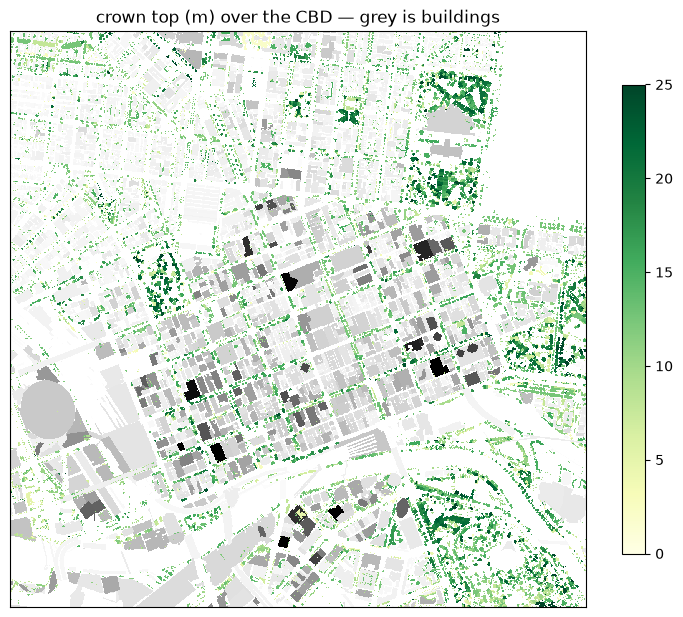

In [209]:
tv = top[VIEW]

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.imshow(dsm[VIEW], cmap="gray_r", vmax=250, interpolation="nearest")
im = ax.imshow(np.ma.masked_where(tv <= 0, tv), cmap="YlGn", vmin=0, vmax=25,
               interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("crown top (m) over the CBD — grey is buildings")
fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()

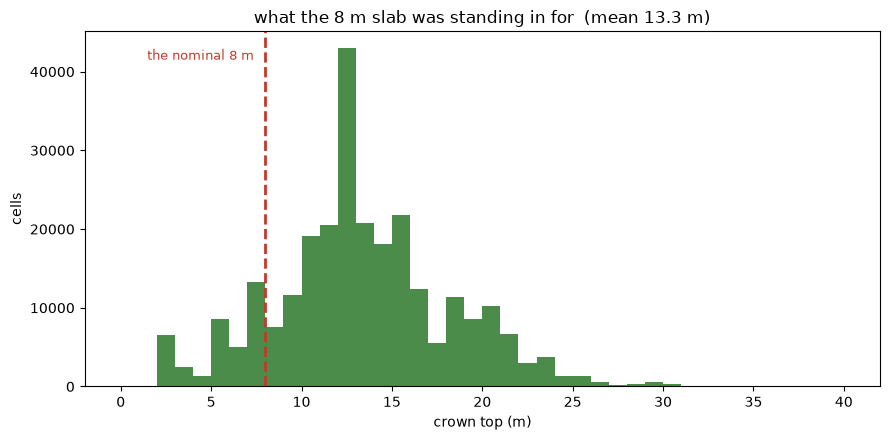

In [210]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(tv[tv > 0], bins=np.arange(0, 41, 1), color="#4c8c4a")
ax.axvline(8.0, color="#c0392b", lw=2, ls="--")
ax.text(7.6, ax.get_ylim()[1] * 0.92, "the nominal 8 m ", color="#c0392b",
        fontsize=9, ha="right")
ax.set_xlabel("crown top (m)"); ax.set_ylabel("cells")
ax.set_title(f"what the 8 m slab was standing in for  "
             f"(mean {tv[tv > 0].mean():.1f} m)")
fig.tight_layout()


## Marching the beam

Step toward the sun a cell at a time: `d` metres out the beam is `d * tan(el)` above the
ground, and a crown intercepts it only where `base(d) <= d * tan(el) < top(d)`. Buildings
are solid so they only need the top; a crown needs both, because the beam can pass under it.

In [211]:
def beam_offsets(az, el, max_h):
    """Integer (dr, dc, distance_m) steps from a cell toward the sun, nearest first."""
    a = np.radians(az)
    reach = max_h / np.tan(np.radians(el))            # longest shadow anything can cast
    k_max = min(reach / CELL, 800)                    # cells; capped so dawn stays tractable

    seen, offs = set(), []
    for k in np.arange(0.25, k_max, 0.25):            # quarter-cell steps, no gaps in the line
        dr, dc = int(round(-k * np.cos(a))), int(round(k * np.sin(a)))
        if (dr, dc) in seen or (dr, dc) == (0, 0):
            continue
        seen.add((dr, dc))
        offs.append((dr, dc, k * CELL))               # first time seen = shortest true distance
    return offs

def shift(a, dr, dc):
    """out[r, c] = a[r + dr, c + dc], zero-padded. What the cell sees dr, dc away."""
    out = np.zeros_like(a)
    Hh, Ww = a.shape
    out[max(-dr, 0):Hh - max(dr, 0), max(-dc, 0):Ww - max(dc, 0)] = \
        a[max(dr, 0):Hh - max(-dr, 0), max(dc, 0):Ww - max(-dc, 0)]
    return out

In [212]:
def shade_at(surface, az, el):
    """01's march, unchanged: True where an opaque height field blocks the beam."""
    if el <= 0:
        return np.ones(surface.shape, bool)
    t = np.tan(np.radians(el))
    blocked = np.zeros(surface.shape, bool)
    for dr, dc, dist in beam_offsets(az, el, surface.max()):
        blocked |= shift(surface, dr, dc) - dist * t > 0
    return blocked

In [213]:
def canopy_at(top, base, az, el):
    """True where a crown SLAB intercepts the beam. Same march, one extra comparison."""
    if el <= 0:
        return np.zeros(top.shape, bool)
    t = np.tan(np.radians(el))
    hit = np.zeros(top.shape, bool)
    for dr, dc, dist in beam_offsets(az, el, top.max()):
        beam = dist * t                                        # beam height at this distance
        hit |= (shift(top, dr, dc) - beam > 0) & (shift(base, dr, dc) - beam <= 0)
    return hit

In [214]:
import pandas as pd
from pvlib.solarposition import get_solarposition

DATE, TZ = CONFIG["date"], "Australia/Melbourne"
t7 = pd.to_datetime([f"{DATE} 07:00"]).tz_localize(TZ)
az, el = get_solarposition(t7, LAT, LON)[["azimuth", "apparent_elevation"]].iloc[0]

print(f"07:00  az {az:.1f}deg (east-south-east)  el {el:.1f}deg")
print(f"the beam is only {np.tan(np.radians(el)):.3f} m up per metre travelled, so it clears")
print(f"  a {base[rr, cc].mean():.1f} m mean crown base at {base[rr, cc].mean() / np.tan(np.radians(el)):5.0f} m out")
print(f"  a {top[rr, cc].mean():.1f} m mean crown top  at {top[rr, cc].mean() / np.tan(np.radians(el)):5.0f} m out")

07:00  az 109.6deg (east-south-east)  el 5.2deg
the beam is only 0.092 m up per metre travelled, so it clears
  a 3.5 m mean crown base at    38 m out
  a 13.5 m mean crown top  at   147 m out


In [215]:
# 01's model against this one at the same instant: one opaque surface with an 8 m canopy
# slab, versus buildings opaque and crowns as a slab with clear air underneath.
surface_flat = np.maximum(dsm, canopy8)              # 01's model: one opaque height field
shade_flat = shade_at(surface_flat, az, el)

shade_crown = shade_at(dsm, az, el) | canopy_at(top, base, az, el)

print(f"shaded at 07:00   flat 8 m slab {shade_flat.mean() * 100:.1f}%"
      f"    crown slab {shade_crown.mean() * 100:.1f}%")
print(f"  newly SUNLIT (the beam now goes under a crown):  "
      f"{(shade_flat & ~shade_crown).mean() * 100:.2f}% of the grid")
print(f"  newly SHADED (crowns are taller than 8 m):       "
      f"{(shade_crown & ~shade_flat).mean() * 100:.2f}% of the grid")

shaded at 07:00   flat 8 m slab 67.5%    crown slab 67.4%
  newly SUNLIT (the beam now goes under a crown):  0.64% of the grid
  newly SHADED (crowns are taller than 8 m):       0.58% of the grid


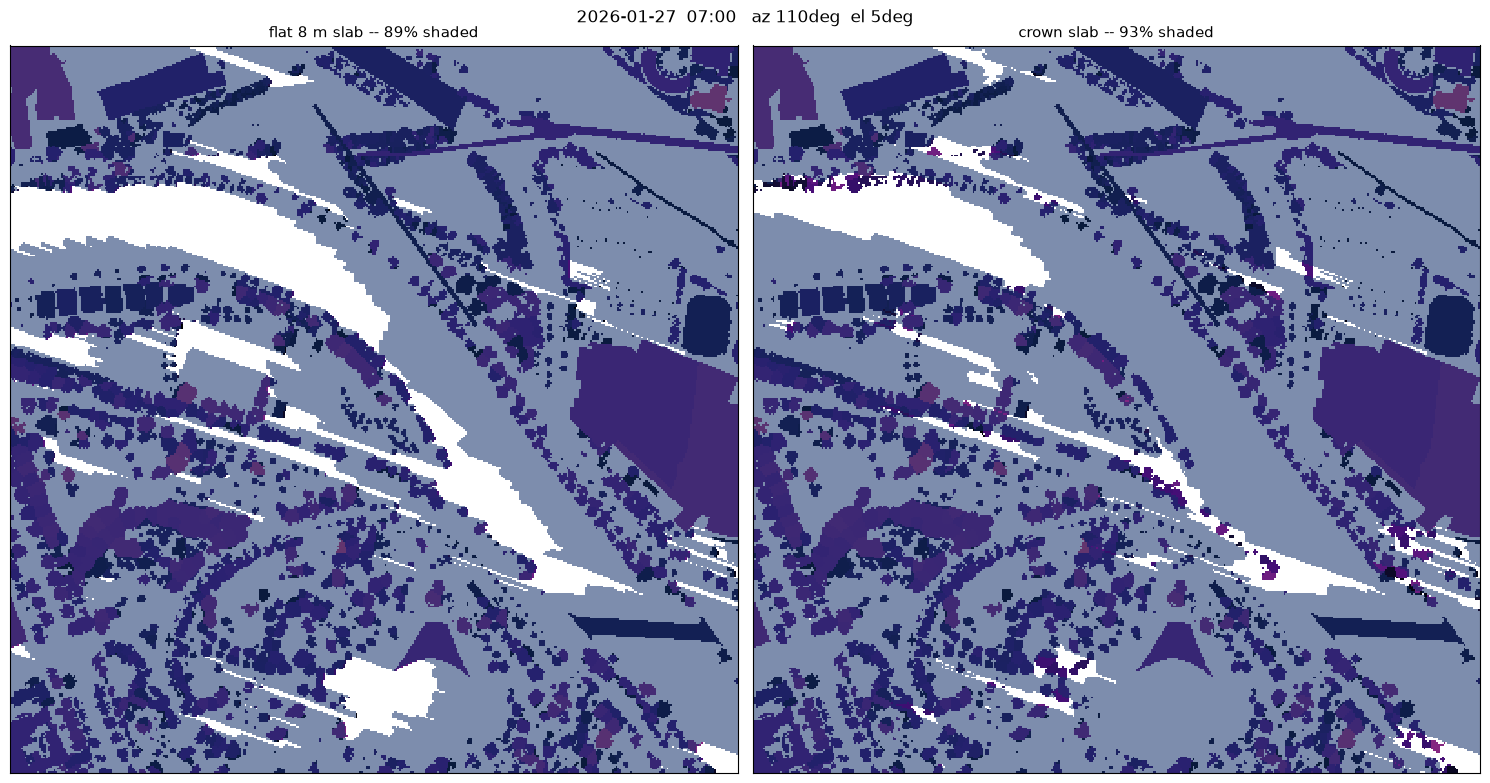

In [216]:
from matplotlib.colors import ListedColormap

# 800m box view over Alexandra Gardens and St Kilda Road 
ZOOM_M = 800
zx, zy = to_m.transform(144.9740, -37.8210)
zr, zc = int((MAXY - zy) / CELL), int((zx - MINX) / CELL)
zh = int(ZOOM_M / CELL / 2)
ZOOM = np.s_[zr - zh:zr + zh, zc - zh:zc + zh]

SHADE_COLOR = ListedColormap(["#12306b"])
surf = np.maximum(dsm, top)[ZOOM]      # open ground masked out, so sunlit pavement is white

def draw_shade(ax, sh, title):
    ax.imshow(np.ma.masked_where(surf <= 0, surf), cmap="magma", vmax=60, interpolation="nearest")
    ax.imshow(np.ma.masked_where(~sh[ZOOM], sh[ZOOM]), cmap=SHADE_COLOR, alpha=0.55,
              interpolation="nearest")
    ax.set_title(title, fontsize=11); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
draw_shade(axes[0], shade_flat, f"flat 8 m slab -- {shade_flat[ZOOM].mean() * 100:.0f}% shaded")
draw_shade(axes[1], shade_crown, f"crown slab -- {shade_crown[ZOOM].mean() * 100:.0f}% shaded")
fig.suptitle(f"{DATE}  07:00   az {az:.0f}deg  el {el:.0f}deg")
fig.tight_layout()